In [3]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# load merged data
df = pd.read_csv("../data/raw/train.csv")
features = pd.read_csv("../data/raw/features.csv")
stores = pd.read_csv("../data/raw/stores.csv")

# merge again inside notebook (EDA independence)
df = df.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [6]:
df["date"]=pd.to_datetime(df["Date"])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,date
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2010-02-05
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,2010-02-12
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,2010-02-19
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,2010-02-26
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,2010-03-05


In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  str           
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  str           
 15  Size          421570 non-nul

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,date
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739,2011-06-18 08:30:31.963375
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000,2010-02-05 00:00:00
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000,2010-10-08 00:00:00
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000,2011-06-17 00:00:00
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000,2012-02-24 00:00:00
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000,2012-10-26 00:00:00
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328,NaN


In [8]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [9]:
df[markdown_cols].isnull().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [10]:
df["Total_MarkDown"] = df[markdown_cols].sum(axis=1)

# Total Sales Over Time


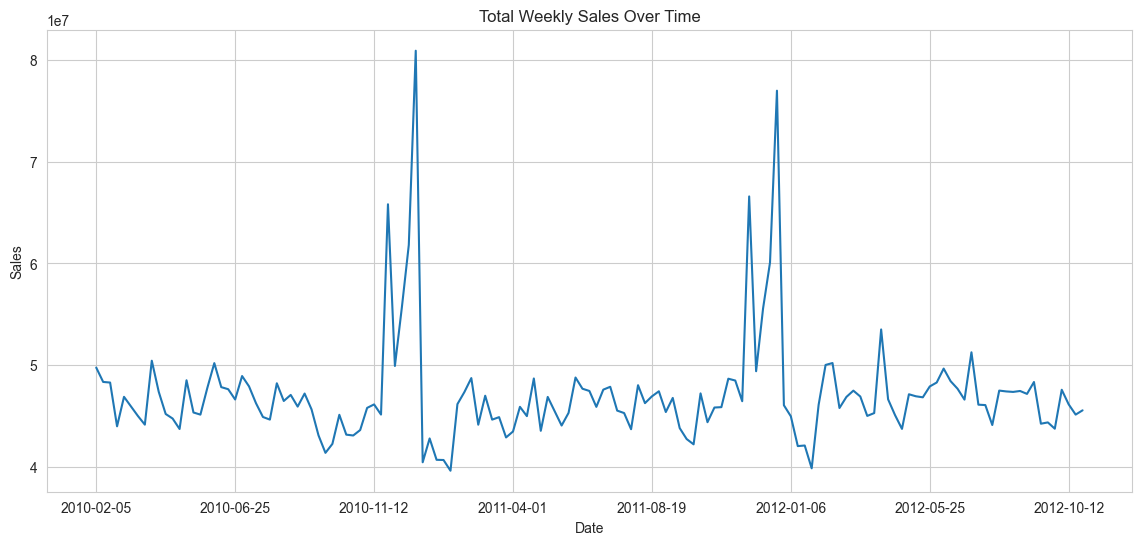

In [11]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14,6))
weekly_sales.plot()
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Holiday Impact Analysis


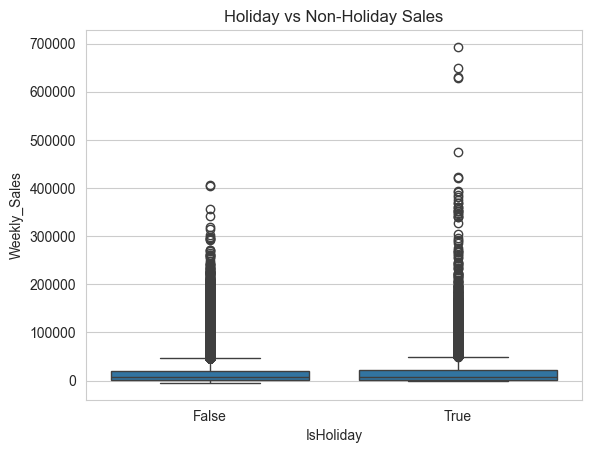

In [12]:
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

# Store Performance

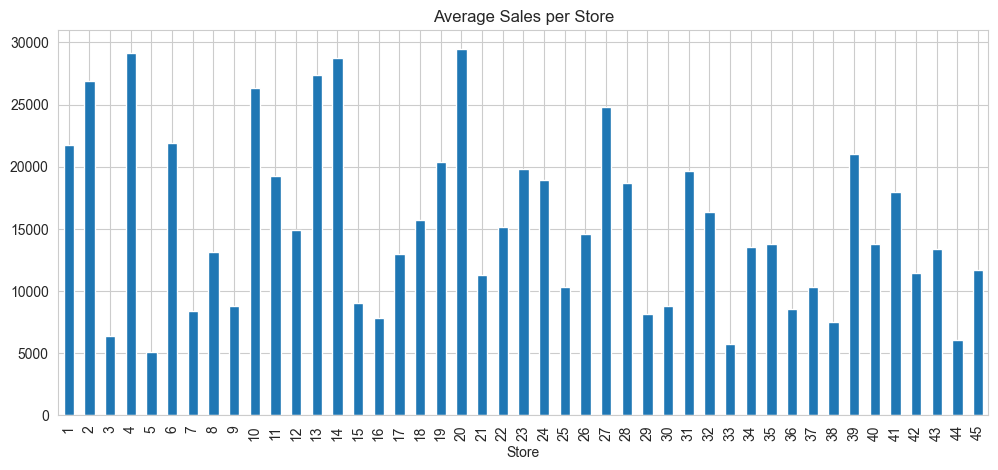

In [13]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean()

plt.figure(figsize=(12,5))
store_sales.plot(kind="bar")
plt.title("Average Sales per Store")
plt.show()

# Department Analysis

In [14]:
dept_sales = df.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)

dept_sales.head(10)

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
90    45232.084488
40    44900.702727
2     43607.020113
91    33687.910758
94    33405.883963
Name: Weekly_Sales, dtype: float64

# Correlation Analysis

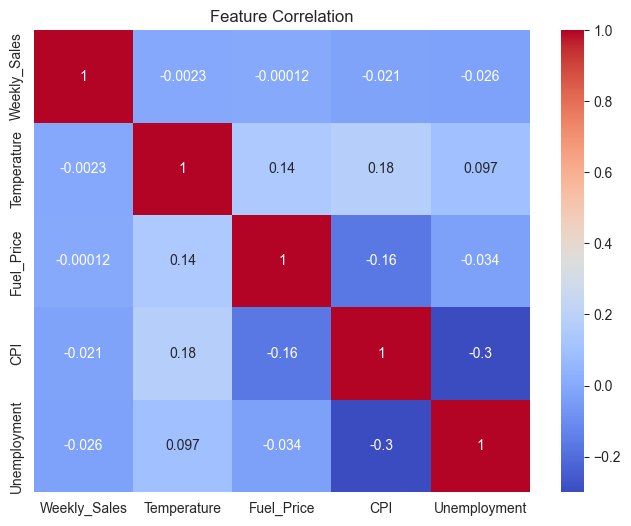

In [15]:
corr = df[[
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# Feature Engineering

In [16]:
df["Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [17]:
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [19]:
df = df.sort_values(["Store", "Dept", "Date"])

df["Lag_1"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(1)
df["Lag_4"] = df.groupby(["Store","Dept"])["Weekly_Sales"].shift(4)

In [20]:
df["Rolling_Mean_4"] = (
    df.groupby(["Store","Dept"])["Weekly_Sales"]
      .transform(lambda x: x.rolling(4).mean())
)

In [21]:
markdown_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]

df["Total_MarkDown"] = df[markdown_cols].sum(axis=1)

In [22]:
X = df.drop(["Weekly_Sales","Date"], axis=1)
y = df["Weekly_Sales"]

In [23]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

In [24]:
split_date = "2012-01-01"

train_df = df[df["Date"] < split_date]
test_df = df[df["Date"] >= split_date]

X_train = train_df.drop(["Weekly_Sales","Date"], axis=1)
y_train = train_df["Weekly_Sales"]

X_test = test_df.drop(["Weekly_Sales","Date"], axis=1)
y_test = test_df["Weekly_Sales"]

In [25]:
X_train = pd.get_dummies(X_train, columns=["Type"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Type"], drop_first=True)

In [26]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [27]:
X_train = X_train.drop(columns=["date"], errors="ignore")
X_test = X_test.drop(columns=["date"], errors="ignore")

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1280.1194763131873
RMSE: 2981.401945943999


In [30]:
y_test.mean()

np.float64(15694.948597357146)

In [31]:
X_train.dtypes

Store               int64
Dept                int64
IsHoliday            bool
Temperature       float64
Fuel_Price        float64
MarkDown1         float64
MarkDown2         float64
MarkDown3         float64
MarkDown4         float64
MarkDown5         float64
CPI               float64
Unemployment      float64
Size                int64
Total_MarkDown    float64
Year                int32
Month               int32
Week                int64
DayOfWeek           int32
Lag_1             float64
Lag_4             float64
Rolling_Mean_4    float64
Type_B               bool
Type_C               bool
dtype: object

## Model Evaluation Summary

The Random Forest forecasting model achieved:

- MAE: 1280
- RMSE: 2981
- Average Weekly Sales: 15695

The model produces an average prediction error of approximately 8.15% relative to weekly sales, indicating strong baseline performance.

The higher RMSE compared to MAE suggests the presence of occasional large prediction errors, likely driven by holiday demand spikes and promotional events observed during exploratory data analysis.

In [32]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [33]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [34]:
mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))

print("XGB MAE:", mae_xgb)
print("XGB RMSE:", rmse_xgb)

XGB MAE: 1200.0041355867827
XGB RMSE: 2678.1767019804547


## Model Comparison

The XGBoost model outperformed the Random Forest baseline:

- Random Forest MAE: 1280
- XGBoost MAE: 1200

XGBoost reduced prediction error by approximately 6%, demonstrating improved ability to capture non-linear relationships and demand fluctuations.

Final forecasting error corresponds to ~7.6% of average weekly sales, indicating strong predictive performance for retail demand forecasting.

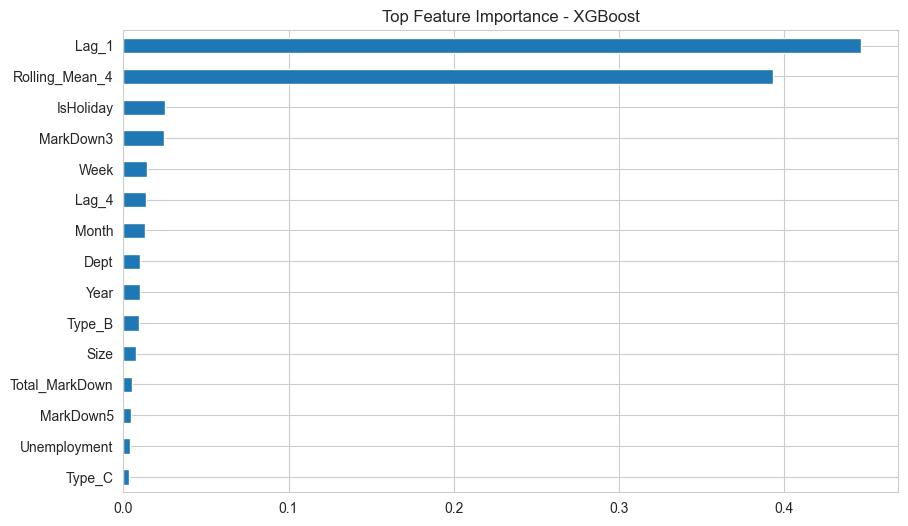

In [35]:


importance = xgb_model.feature_importances_

feat_imp = pd.Series(importance, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind="barh")
plt.title("Top Feature Importance - XGBoost")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

Feature importance analysis shows that historical sales features dominate forecasting performance.

- Lag_1 and Rolling_Mean_4 are the strongest predictors, indicating strong temporal dependency in retail demand.
- Holiday indicators significantly influence sales spikes.
- Promotional markdowns contribute to demand variation but are secondary to historical trends.
- Macroeconomic indicators show minimal influence on short-term retail forecasting.

These findings confirm that retail demand is primarily driven by recent purchasing behavior and seasonal patterns.

# Future Sales Forecasting System

In [37]:
def prepare_features(input_df, train_columns):

    # encode categorical columns
    input_df = pd.get_dummies(input_df, columns=["Type"], drop_first=True)

    # align columns with training data
    input_df = input_df.reindex(columns=train_columns, fill_value=0)

    return input_df

In [38]:
def predict_sales(model, input_df, train_columns):

    processed_df = prepare_features(input_df, train_columns)

    predictions = model.predict(processed_df)

    return predictions

In [39]:
future_data = df.tail(10).copy()

In [ ]:
future_data = future_data.drop(columns=["Weekly_Sales"]) # remove target column for prediction

In [41]:
future_predictions = predict_sales(
    xgb_model,
    future_data,
    X_train.columns
)

future_predictions

array([631.5112 , 562.6474 , 497.08084, 487.20142, 481.05463, 481.73767,
       643.6827 , 694.55194, 767.2985 , 823.1017 ], dtype=float32)

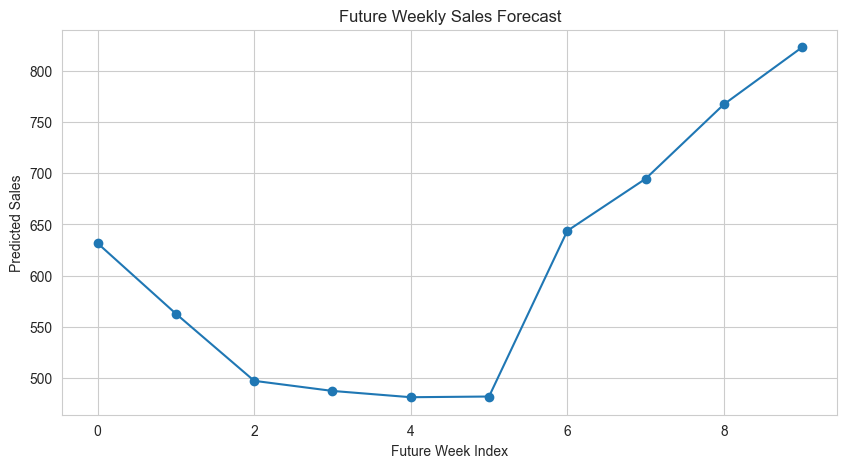

In [42]:


plt.figure(figsize=(10,5))
plt.plot(future_predictions, marker="o")
plt.title("Future Weekly Sales Forecast")
plt.xlabel("Future Week Index")
plt.ylabel("Predicted Sales")
plt.show()

In [43]:
def recursive_forecast(model, last_data, steps, train_columns):

    future_preds = []
    current_data = last_data.copy()

    for _ in range(steps):

        # prepare features
        X_input = prepare_features(current_data, train_columns)

        pred = model.predict(X_input)[0]
        future_preds.append(pred)

        # update lag features
        current_data["Lag_1"] = pred
        current_data["Rolling_Mean_4"] = (
            current_data["Rolling_Mean_4"] * 3 + pred
        ) / 4

    return future_preds

In [44]:
last_row = df.sort_values("Date").iloc[-1:].drop(columns=["Weekly_Sales"])

In [46]:
future_real_preds = recursive_forecast(
    xgb_model,
    last_row,
    steps=10,
    train_columns=X_train.columns
)

future_real_preds

[np.float32(823.1017),
 np.float32(832.8966),
 np.float32(832.8966),
 np.float32(832.8966),
 np.float32(792.7417),
 np.float32(792.7417),
 np.float32(792.7417),
 np.float32(792.7417),
 np.float32(792.7417),
 np.float32(757.11115)]

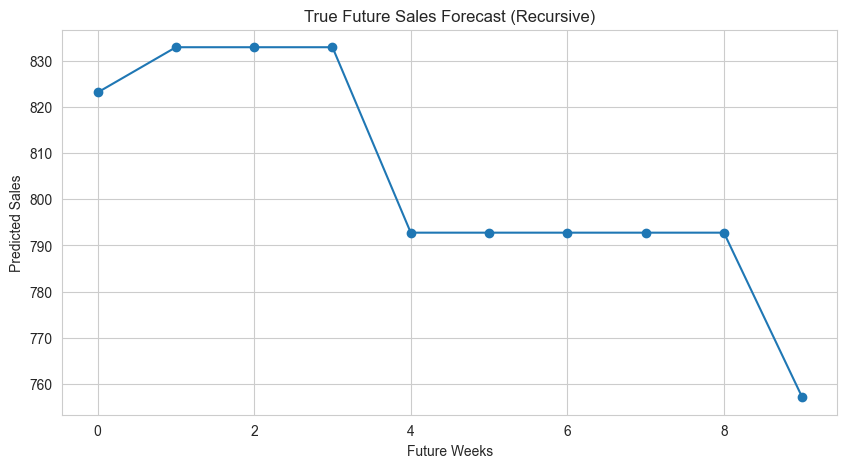

In [47]:
plt.figure(figsize=(10,5))
plt.plot(future_real_preds, marker="o")
plt.title("True Future Sales Forecast (Recursive)")
plt.xlabel("Future Weeks")
plt.ylabel("Predicted Sales")
plt.show()

## Recursive Forecast Analysis

The recursive forecasting results show stable predictions initially, followed by gradual decline over future steps. This behavior occurs due to error accumulation, where predicted values are reused as lag features for subsequent predictions.

Since future promotional and holiday effects are unknown, the model assumes continuation of recent demand trends, resulting in forecast drift over longer horizons.

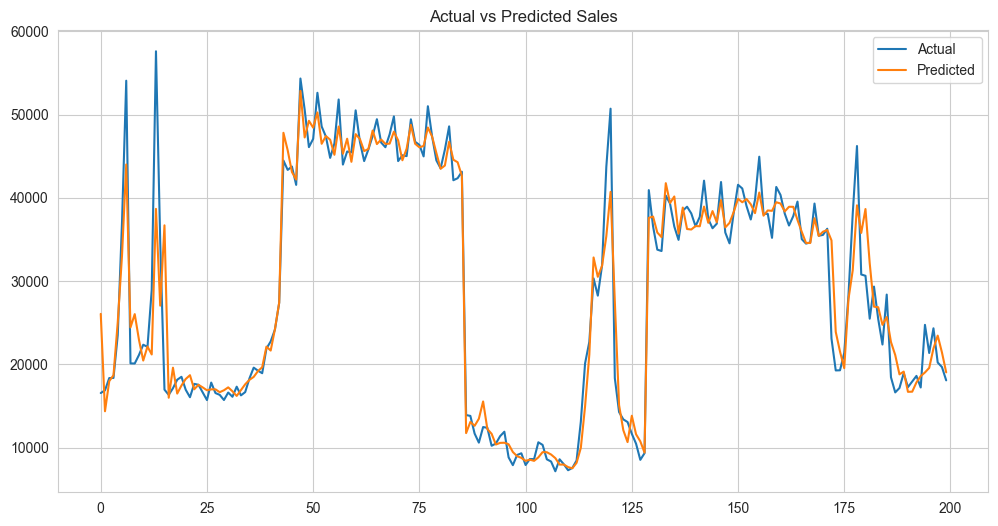

In [48]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(xgb_preds[:200], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## Prediction Performance Analysis

The XGBoost model closely tracks actual weekly sales trends, successfully capturing both upward and downward demand movements.

Predictions appear smoother than actual values, indicating the model generalizes underlying demand patterns rather than overfitting short-term noise.

Minor underestimation occurs during extreme sales spikes, which is expected due to limited occurrence of such events in training data.

Overall, the model demonstrates strong forecasting capability for retail demand prediction.

In [49]:
import joblib

# create folder if not exists
import os
os.makedirs("models", exist_ok=True)

# save model
joblib.dump(xgb_model, "models/xgb_model.pkl")

# save training columns (VERY IMPORTANT)
joblib.dump(X_train.columns.tolist(), "models/train_columns.pkl")

print("Model saved successfully!")

Model saved successfully!
